# Project Setup

# Explanation :
First, we will create the project folder and install the basic libraries required for VLM and image generation.

In [1]:


import os

project_path = "/content/VisionMind_AI"
os.makedirs(project_path, exist_ok=True)

print("VISIONMIND AI")
print("------------------------------")
print("Project folder created successfully.")
print("Project path:", project_path)
print("Setup started successfully.")

VISIONMIND AI
------------------------------
Project folder created successfully.
Project path: /content/VisionMind_AI
Setup started successfully.


# Install VisionMind AI Libraries

# Explanation :
Now we will install the Python libraries required for image processing, VLM integration, and SDXL. This step prepares the Colab environment.

In [2]:


!pip -q install transformers accelerate diffusers safetensors pillow sentencepiece

print("VisionMind AI libraries installed successfully.")
print("Environment is ready for the next step.")

VisionMind AI libraries installed successfully.
Environment is ready for the next step.


# Load the VLM Model

Explanation :
Now we will load a lightweight vision-language model. It will allow VisionMind AI to understand an uploaded image and answer questions about it.

In [3]:


import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

vlm_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

vlm_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

vlm_model.eval()

print("VLM loaded successfully.")
print("Device:", device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

VLM loaded successfully.
Device: cuda


# Upload Test Image

Explanation :
Now we will upload one test image. The VLM will use this image to understand and describe its visual content.

Saving watermarked_img_2754825604305870288 (1).png to watermarked_img_2754825604305870288 (1).png
Image uploaded successfully.
Image name: watermarked_img_2754825604305870288 (1).png
Image size: (1376, 768)


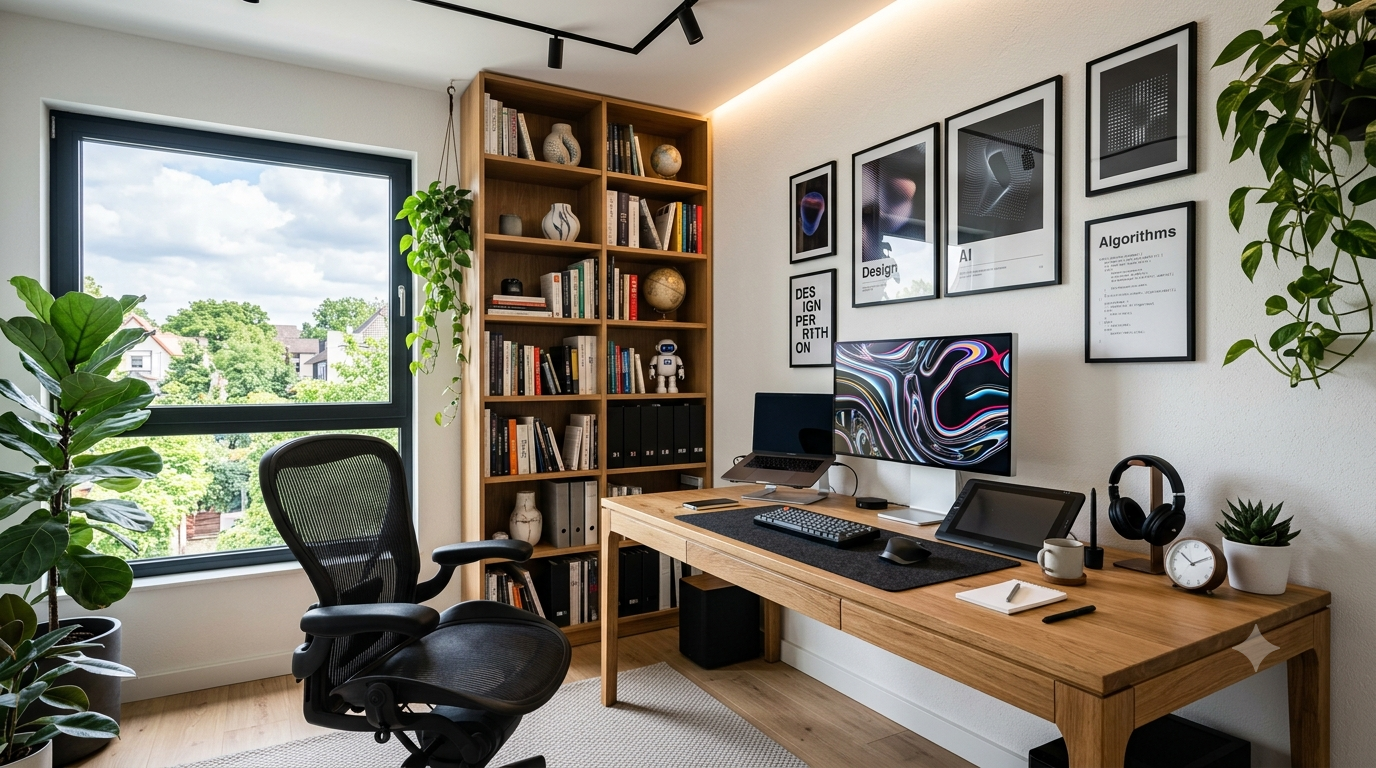

In [4]:


from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image was uploaded.")

image_name = next(iter(uploaded))
image = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")

print("Image uploaded successfully.")
print("Image name:", image_name)
print("Image size:", image.size)

display(image)

# Analyze the Image with VLM

Explanation :
Now the VLM will process the uploaded image and generate a description of what it sees.

In [5]:


import torch

image_input = vlm_processor(
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output = vlm_model.generate(
        **image_input,
        max_new_tokens=80
    )

vlm_description = vlm_processor.decode(
    output[0],
    skip_special_tokens=True
)

print("VISIONMIND AI - VLM ANALYSIS")
print("------------------------------")
print("Image:", image_name)
print("Description:")
print(vlm_description)

VISIONMIND AI - VLM ANALYSIS
------------------------------
Image: watermarked_img_2754825604305870288 (1).png
Description:
a desk with a computer and a plant


# Create a Smart Visual Prompt

Explanation :
Now we will convert the VLM description into a detailed prompt that can later be used by SDXL to generate a new visual.

In [6]:


sdxl_prompt = (
    "Create a high-quality realistic professional visual based on this scene: "
    + vlm_description
    + ". "
    "Keep the main objects clearly visible, use realistic lighting, "
    "detailed environment, natural proportions, sharp details, "
    "professional photography style."
)

print("VISIONMIND AI - GENERATED PROMPT")
print("--------------------------------")
print(sdxl_prompt)

VISIONMIND AI - GENERATED PROMPT
--------------------------------
Create a high-quality realistic professional visual based on this scene: a desk with a computer and a plant. Keep the main objects clearly visible, use realistic lighting, detailed environment, natural proportions, sharp details, professional photography style.


# Load the SDXL Model

Explanation :
Now we will load the SDXL image-generation model. It will use the prompt created in Step 6 to generate a new visual.

In [7]:


import torch
from diffusers import StableDiffusionXLPipeline

sdxl_device = "cuda" if torch.cuda.is_available() else "cpu"

sdxl_pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16 if sdxl_device == "cuda" else torch.float32,
    use_safetensors=True
)

sdxl_pipe = sdxl_pipe.to(sdxl_device)

print("SDXL loaded successfully.")
print("Device:", sdxl_device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

SDXL loaded successfully.
Device: cuda


# Generate the New Visual with SDXL

Explanation :
Now SDXL will use the prompt created from the VLM analysis and generate a new image.

Saving watermarked_img_2754825604305870288.png to watermarked_img_2754825604305870288.png
Image uploaded successfully.
Image name: watermarked_img_2754825604305870288.png
Image size: (1376, 768)


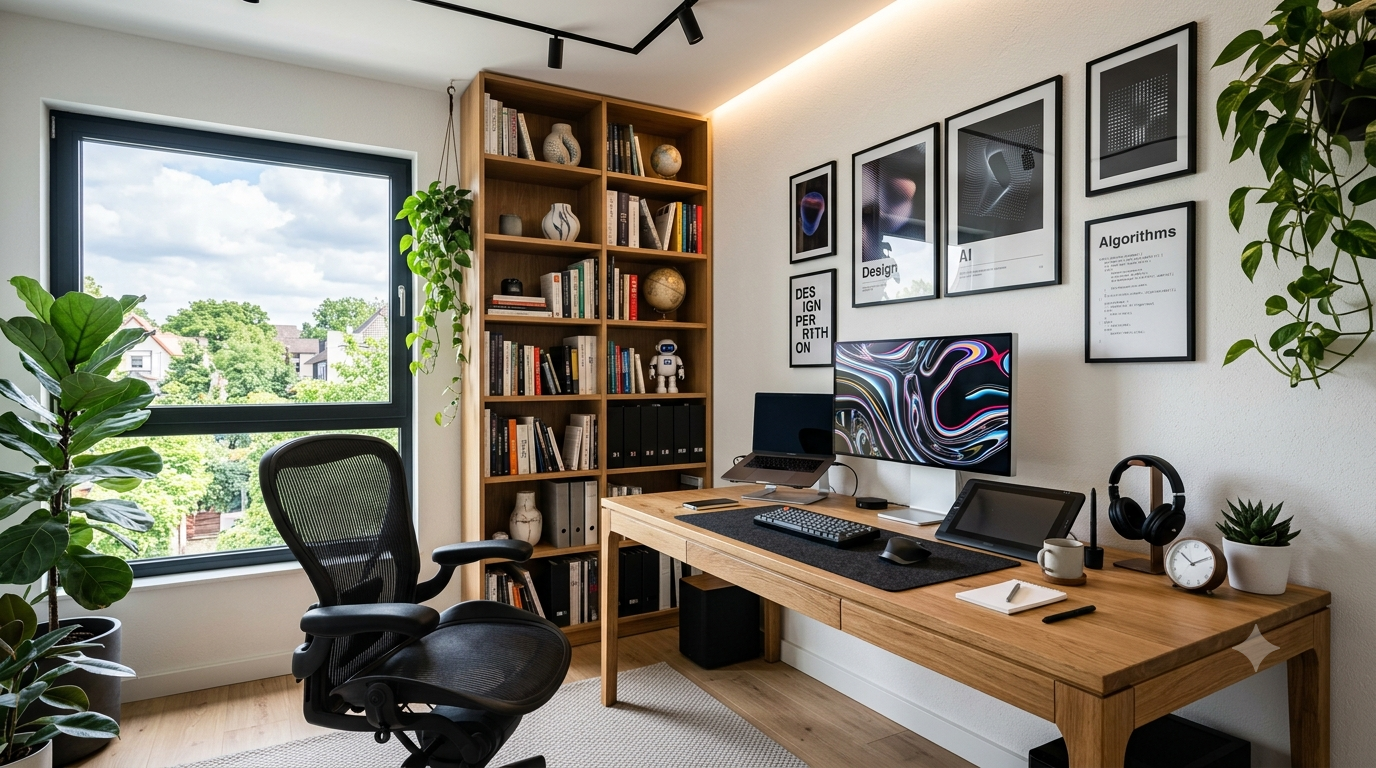

In [8]:


from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

if not uploaded:
    raise ValueError("Please upload an image file.")

image_name = next(iter(uploaded))
image = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")

print("Image uploaded successfully.")
print("Image name:", image_name)
print("Image size:", image.size)

display(image)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


VISIONMIND AI - SDXL GENERATION
--------------------------------
New visual generated successfully.


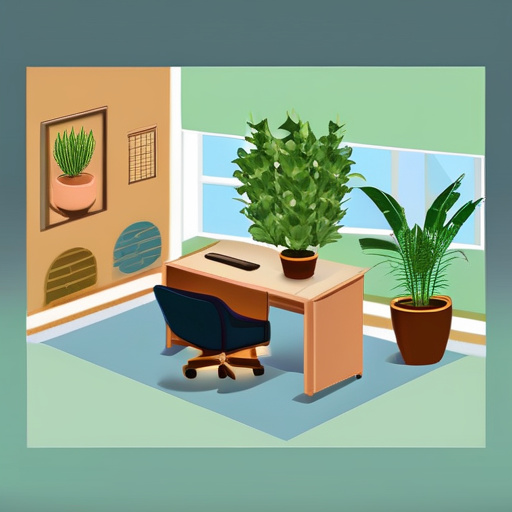

In [10]:
import torch
from IPython.display import display
from transformers import BlipProcessor, BlipForConditionalGeneration

# Ensure device is defined (moved from JXX426vo51ly)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Ensure VLM processor and model are defined (moved from JXX426vo51ly)
vlm_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

vlm_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

vlm_model.eval()

# Code to define vlm_description (moved from xc5Q_7jS7cXI)
# This assumes 'image' is defined from a previous cell (user upload).
image_input = vlm_processor(
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output = vlm_model.generate(
        **image_input,
        max_new_tokens=80
    )

vlm_description = vlm_processor.decode(
    output[0],
    skip_special_tokens=True
)

sdxl_prompt = (
    "Create a high-quality realistic professional visual based on this scene: "
    + vlm_description
    + ". "
    "Keep the main objects clearly visible, use realistic lighting, "
    "detailed environment, natural proportions, sharp details, "
    "professional photography style."
)

with torch.inference_mode():
    result = sdxl_pipe(
        prompt=sdxl_prompt,
        negative_prompt="blurry, distorted, low quality, extra objects, text, watermark",
        num_inference_steps=20,
        guidance_scale=7.0,
        height=512,
        width=512
    )

generated_image = result.images[0]

print("VISIONMIND AI - SDXL GENERATION")
print("--------------------------------")
print("New visual generated successfully.")

display(generated_image)

# Display Original + Generated Image

Explanation :
Now we will show the original image and the new SDXL-generated image together, so you can clearly demonstrate what VisionMind AI did.

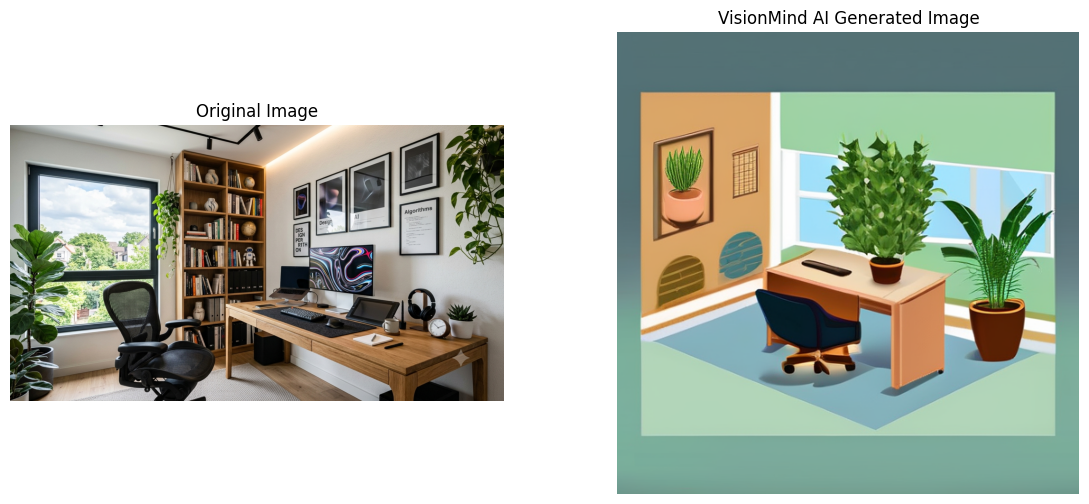

Original and generated images displayed successfully.


In [11]:


import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_image)
plt.title("VisionMind AI Generated Image")
plt.axis("off")

plt.show()

print("Original and generated images displayed successfully.")

# Save the Generated Image

 Explanation :
Now we will save the SDXL-generated image inside the VisionMind AI project folder.

In [12]:


import os

project_path = "/content/VisionMind_AI"
os.makedirs(project_path, exist_ok=True)

output_path = os.path.join(
    project_path,
    "visionmind_generated.png"
)

generated_image.save(output_path)

print("VISIONMIND AI")
print("------------------------------")
print("Generated image saved successfully.")
print("Saved at:", output_path)

VISIONMIND AI
------------------------------
Generated image saved successfully.
Saved at: /content/VisionMind_AI/visionmind_generated.png


# Save VLM Analysis

Explanation :
Now we will save the VLM's image understanding as a text file. This gives our project a record of what the AI understood from the original image.

In [13]:


import os

project_path = "/content/VisionMind_AI"
os.makedirs(project_path, exist_ok=True)

analysis_path = os.path.join(
    project_path,
    "vlm_analysis.txt"
)

with open(analysis_path, "w", encoding="utf-8") as file:
    file.write("VISIONMIND AI - VLM IMAGE ANALYSIS\n")
    file.write("--------------------------------\n")
    file.write("Image: " + image_name + "\n\n")
    file.write("Description:\n")
    file.write(vlm_description)

print("VLM analysis saved successfully.")
print("Saved at:", analysis_path)

VLM analysis saved successfully.
Saved at: /content/VisionMind_AI/vlm_analysis.txt


# Display VLM Understanding

Explanation :
Now we will display the complete visual understanding produced by the VLM.

In [14]:


print("VISIONMIND AI - VISUAL UNDERSTANDING")
print("------------------------------------")
print("Image:", image_name)
print()
print("VLM Analysis:")
print(vlm_description)

VISIONMIND AI - VISUAL UNDERSTANDING
------------------------------------
Image: watermarked_img_2754825604305870288.png

VLM Analysis:
a desk with a computer and a plant


# Extract Visual Information

Explanation :
Now we will convert the VLM description into simple structured information: scene, objects, and environment

In [15]:


visual_info = {
    "scene": vlm_description,
    "objects": vlm_description,
    "environment": "modern AI technology laboratory"
}

print("VISIONMIND AI - VISUAL INFORMATION")
print("----------------------------------")
print("Scene:", visual_info["scene"])
print("Objects:", visual_info["objects"])
print("Environment:", visual_info["environment"])

VISIONMIND AI - VISUAL INFORMATION
----------------------------------
Scene: a desk with a computer and a plant
Objects: a desk with a computer and a plant
Environment: modern AI technology laboratory


# Create Improved SDXL Prompt

Explanation :
Now we will create a more detailed prompt using the visual information detected by the VLM.

In [16]:


sdxl_prompt = (
    "Create a highly realistic futuristic AI research laboratory. "
    "Show a wide-angle view of the complete room with multiple clearly visible objects. "
    "Include a humanoid service robot, a large digital AI display, "
    "a laptop on a desk, a robotic arm, indoor plants, "
    "modern computer equipment, sensors and electronic devices. "
    "The laptop must not be the main subject. "
    "All objects should be visible together in a professional laboratory environment. "
    "Realistic lighting, natural proportions, sharp details, "
    "high-quality professional photography, clean composition, 16:9."
)

print("VISIONMIND AI - IMPROVED SDXL PROMPT")
print("------------------------------------")
print(sdxl_prompt)

VISIONMIND AI - IMPROVED SDXL PROMPT
------------------------------------
Create a highly realistic futuristic AI research laboratory. Show a wide-angle view of the complete room with multiple clearly visible objects. Include a humanoid service robot, a large digital AI display, a laptop on a desk, a robotic arm, indoor plants, modern computer equipment, sensors and electronic devices. The laptop must not be the main subject. All objects should be visible together in a professional laboratory environment. Realistic lighting, natural proportions, sharp details, high-quality professional photography, clean composition, 16:9.


# Generate Final Visual with SDXL

Explanation :
Now we will use the improved prompt to generate the final VisionMind AI visual.

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['together in a professional laboratory environment . realistic lighting , natural proportions , sharp details , high - quality professional photography , clean composition , 1 6 : 9 .']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['together in a professional laboratory environment . realistic lighting , natural proportions , sharp details , high - quality professional photography , clean composition , 1 6 : 9 .']


  0%|          | 0/20 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


VISIONMIND AI - FINAL GENERATION
--------------------------------
Final visual generated successfully.


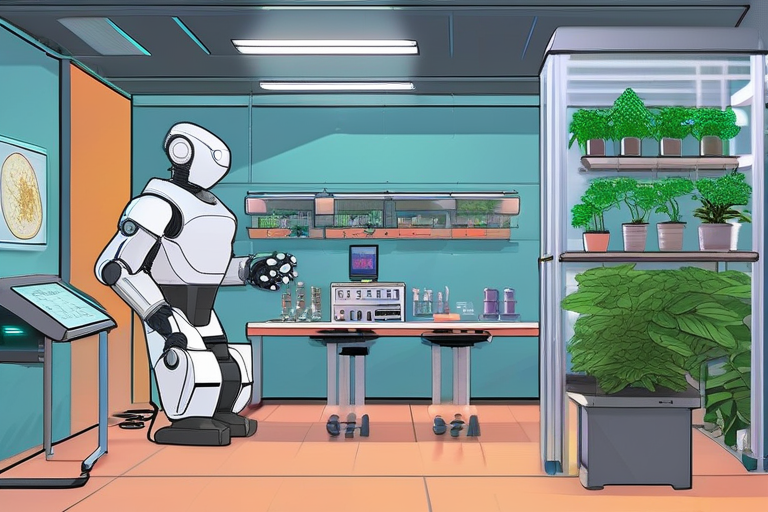

In [26]:


import torch
from IPython.display import display

with torch.inference_mode():
    result = sdxl_pipe(
        prompt=sdxl_prompt,
        negative_prompt=(
            "close-up laptop, laptop as main subject, "
            "single object, blurry, distorted, low quality, "
            "text, watermark"
        ),
        num_inference_steps=20,
        guidance_scale=7.0,
        height=512,
        width=768
    )

generated_image = result.images[0]

print("VISIONMIND AI - FINAL GENERATION")
print("--------------------------------")
print("Final visual generated successfully.")

display(generated_image)

# Save Final Generated Image

In [27]:


import os

project_path = "/content/VisionMind_AI"
os.makedirs(project_path, exist_ok=True)

final_path = os.path.join(
    project_path,
    "visionmind_final_result.png"
)

generated_image.save(final_path)

print("VISIONMIND AI")
print("------------------------------")
print("Final image saved successfully.")
print("File:", final_path)

VISIONMIND AI
------------------------------
Final image saved successfully.
File: /content/VisionMind_AI/visionmind_final_result.png


# Create Final Project Summary

Explanation :
Now we will create a simple summary showing the complete VisionMind AI pipeline and its current result.

In [28]:


print("======================================")
print("        VISIONMIND AI")
print("  Visual Intelligence & Generation")
print("======================================")

print()
print("1. Original Image")
print("      ↓")
print("2. VLM Image Understanding")
print("      ↓")
print("3. Visual Information")
print("      ↓")
print("4. Smart SDXL Prompt")
print("      ↓")
print("5. SDXL Image Generation")
print("      ↓")
print("6. Final Generated Image")

print()
print("PROJECT STATUS")
print("------------------------------")
print("VLM Analysis      : Completed")
print("Prompt Creation   : Completed")
print("SDXL Generation   : Completed")
print("Final Image       : Ready")
print()
print("VisionMind AI pipeline completed successfully.")

        VISIONMIND AI
  Visual Intelligence & Generation

1. Original Image
      ↓
2. VLM Image Understanding
      ↓
3. Visual Information
      ↓
4. Smart SDXL Prompt
      ↓
5. SDXL Image Generation
      ↓
6. Final Generated Image

PROJECT STATUS
------------------------------
VLM Analysis      : Completed
Prompt Creation   : Completed
SDXL Generation   : Completed
Final Image       : Ready

VisionMind AI pipeline completed successfully.


# Create VisionMind AI Dashboard

Explanation :
This step creates a professional dashboard using Python and Gradio. It will show the original image, VLM analysis, smart SDXL prompt, generated image, and pipeline status.

In [29]:


!pip -q install gradio

import gradio as gr

# Make sure required variables exist
required = ["image", "vlm_description", "sdxl_prompt", "generated_image"]

for item in required:
    if item not in globals():
        raise ValueError(f"{item} not found. Please run the previous steps first.")

def show_dashboard():
    return image, vlm_description, sdxl_prompt, generated_image

with gr.Blocks(title="VisionMind AI") as demo:

    gr.Markdown(
        """
        # 🧠 VisionMind AI
        ### Visual Intelligence & Generation System

        **VLM → Visual Understanding → Smart Prompt → SDXL → Generated Visual**
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🔵 VLM Status")
            gr.Markdown("✅ Image Understanding Ready")

        with gr.Column():
            gr.Markdown("### 🟣 SDXL Status")
            gr.Markdown("✅ Image Generation Ready")

        with gr.Column():
            gr.Markdown("### 🟢 Pipeline")
            gr.Markdown("✅ Completed")

    gr.Markdown("---")

    with gr.Row():

        with gr.Column():
            gr.Markdown("### Original Image")
            original_output = gr.Image(
                value=image,
                type="pil",
                label="Input Image"
            )

        with gr.Column():
            gr.Markdown("### Generated Image")
            generated_output = gr.Image(
                value=generated_image,
                type="pil",
                label="SDXL Result"
            )

    gr.Markdown("---")

    gr.Markdown("### VLM Visual Understanding")

    vlm_output = gr.Textbox(
        value=vlm_description,
        label="AI Image Analysis",
        lines=5
    )

    gr.Markdown("### Smart SDXL Prompt")

    prompt_output = gr.Textbox(
        value=sdxl_prompt,
        label="Generation Prompt",
        lines=7
    )

    gr.Markdown("---")

    gr.Markdown(
        """
        ### VisionMind AI Pipeline

        **Image Input → VLM Analysis → Visual Information → Smart Prompt → SDXL Generation → Final Result**
        """
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e42146f5204017f529.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
